<a href="https://colab.research.google.com/github/danilomashiba/copa2026/blob/main/analise_copa2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 0 — Download e preparação

Optei pelo KaggleHub dentro do Google Colab para automatizar o download e tornar o processo reproduzível. A versão 1 do dataset foi fixada para evitar que futuras atualizações alterem os dados utilizados na análise.

Para verificar o arquivo, foram conferidos nome, tamanho, dimensões, SHA-256 e os primeiros registros do dataset.

In [68]:
# Instalação da biblioteca KaggleHub
!pip install -q kagglehub

import os
import hashlib
import kagglehub
import numpy as np
import pandas as pd

In [69]:
# Dataset utilizado
HANDLE = "rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/versions/1"

# Download do dataset
pasta = kagglehub.dataset_download(HANDLE)

print("Pasta do dataset:", pasta)
print("Arquivos baixados:", os.listdir(pasta))

Pasta do dataset: /root/.cache/kagglehub/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/versions/1
Arquivos baixados: ['fifa_world_cup_2026_player_performance.csv']


In [70]:
# Caminho do arquivo CSV
arquivo = "fifa_world_cup_2026_player_performance.csv"
caminho_csv = os.path.join(pasta, arquivo)

# Verificação do tamanho
tamanho_mb = os.path.getsize(caminho_csv) / 1_000_000

print("Nome do arquivo:", arquivo)
print("Tamanho (MB):", round(tamanho_mb, 2))

Nome do arquivo: fifa_world_cup_2026_player_performance.csv
Tamanho (MB): 17.2


In [71]:
# Cálculo do SHA-256
with open(caminho_csv, "rb") as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print("SHA-256:", sha256)

SHA-256: 322c5efd933578a61ac6de612b4400011849efa7c6a1b88037be67f100fb4e99


In [72]:
# Carregamento do dataset
df = pd.read_csv(caminho_csv)

print("Linhas x colunas:", df.shape)

# Inspeção inicial
df.head()

Linhas x colunas: (54600, 75)


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


# Parte 1 — Primeiro contato e sanidade dos dados

### T1.1 — Tamanho e memória

In [73]:
# Dimensões do dataset
linhas, colunas = df.shape

# Consumo total de memória
memoria_bytes = df.memory_usage(deep=True).sum()
memoria_mb = memoria_bytes / (1024 ** 2)

print(f"Linhas: {linhas:,}")
print(f"Colunas: {colunas}")
print(f"Memória utilizada: {memoria_mb:.2f} MB")

Linhas: 54,600
Colunas: 75
Memória utilizada: 67.27 MB


In [74]:
# Memória utilizada por coluna
memoria_colunas = (
    df.memory_usage(deep=True)
      .sort_values(ascending=False)
      .to_frame(name="memoria_bytes")
)

memoria_colunas["memoria_mb"] = memoria_colunas["memoria_bytes"] / (1024 ** 2)

memoria_colunas.head(10)

,memoria_bytes,memoria_mb
stadium,3448068,3.288334
player_name,3430759,3.271827
tournament_stage,3289104,3.136734
club_name,3272842,3.121225
match_date,3221400,3.072166
city,3179436,3.032146
position,3145800,3.000069
nationality,3104062,2.960264
team,3066778,2.924707
opponent_team,3066778,2.924707


In [75]:
# Contar quantas colunas existem de cada tipo de dado
df.dtypes.value_counts()

,count
int64,43
float64,18
object,14


In [76]:
# Verificar a estrutura do DataFrame, tipos das colunas e presença de valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [77]:
# Medir a cardinalidade das colunas de texto para identificar possíveis candidatas a category

cardinalidade_obj = pd.DataFrame({
    "valores_unicos": df.select_dtypes(include="object").nunique(),
    "total_linhas": len(df)
})

cardinalidade_obj["percentual_unico"] = (
    cardinalidade_obj["valores_unicos"] / cardinalidade_obj["total_linhas"] * 100
)

cardinalidade_obj.sort_values("valores_unicos")

,valores_unicos,total_linhas,percentual_unico
preferred_foot,2,54600,0.003663
match_result,3,54600,0.005495
position,4,54600,0.007326
tournament_stage,7,54600,0.012821
city,16,54600,0.029304
stadium,16,54600,0.029304
team,48,54600,0.087912
nationality,48,54600,0.087912
opponent_team,48,54600,0.087912
match_date,51,54600,0.093407


In [78]:
# Criar uma cópia do dataset para realizar as otimizações sem alterar o DataFrame original
df_otimizado = df.copy()

In [79]:
# Converter colunas de texto repetitivas para o tipo category

colunas_categoricas = [
    "preferred_foot",
    "match_result",
    "position",
    "tournament_stage",
    "city",
    "stadium",
    "team",
    "nationality",
    "opponent_team",
    "club_name",
    "player_name"
]

df_otimizado[colunas_categoricas] = (
    df_otimizado[colunas_categoricas].astype("category")
)

In [80]:
# Converter a coluna de data para o tipo datetime
df_otimizado["match_date"] = pd.to_datetime(df_otimizado["match_date"])

In [81]:
# Comparar o consumo de memória antes e depois da conversão das colunas de texto

memoria_original = df.memory_usage(deep=True).sum() / (1024 ** 2)
memoria_otimizada = df_otimizado.memory_usage(deep=True).sum() / (1024 ** 2)

reducao = (1 - memoria_otimizada / memoria_original) * 100

print(f"Memória original: {memoria_original:.2f} MB")
print(f"Memória após conversões: {memoria_otimizada:.2f} MB")
print(f"Redução: {reducao:.1f}%")

Memória original: 67.28 MB
Memória após conversões: 32.31 MB
Redução: 52.0%


In [82]:
# Reduzir o tamanho dos tipos inteiros e decimais quando possível

for coluna in df_otimizado.select_dtypes(include="int64").columns:
    df_otimizado[coluna] = pd.to_numeric(
        df_otimizado[coluna],
        downcast="integer"
    )

for coluna in df_otimizado.select_dtypes(include="float64").columns:
    df_otimizado[coluna] = pd.to_numeric(
        df_otimizado[coluna],
        downcast="float"
    )

In [83]:
# Comparar a memória após a otimização dos tipos numéricos

memoria_final = df_otimizado.memory_usage(deep=True).sum() / (1024 ** 2)

reducao_final = (1 - memoria_final / memoria_original) * 100

print(f"Memória original: {memoria_original:.2f} MB")
print(f"Memória final: {memoria_final:.2f} MB")
print(f"Redução total: {reducao_final:.1f}%")

Memória original: 67.28 MB
Memória final: 13.15 MB
Redução total: 80.5%


In [84]:
# Validar se a quantidade de linhas e colunas permaneceu igual

print("Dimensões originais:", df.shape)
print("Dimensões otimizadas:", df_otimizado.shape)
print("Dimensões iguais:", df.shape == df_otimizado.shape)

Dimensões originais: (54600, 75)
Dimensões otimizadas: (54600, 75)
Dimensões iguais: True


### **T1.2 — Mapa de qualidade**

In [85]:
# Criar o mapa geral de qualidade com tipo, nulos e cardinalidade de cada coluna

mapa_qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "percentual_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

mapa_qualidade["percentual_unico"] = (
    mapa_qualidade["valores_unicos"] / len(df) * 100
).round(2)

# Ordenar pelas colunas de maior cardinalidade

mapa_qualidade_ordenado = mapa_qualidade.sort_values(
    "valores_unicos",
    ascending=False
)

# Exibir todas as 75 colunas

with pd.option_context("display.max_rows", None):
    display(mapa_qualidade_ordenado)

,tipo,nulos,percentual_nulos,valores_unicos,percentual_unico
player_id,object,0,0.0,1248,2.29
market_value_eur,int64,0,0.0,1246,2.28
player_name,object,0,0.0,1245,2.28
match_id,object,0,0.0,1050,1.92
offensive_contribution,float64,0,0.0,981,1.80
defensive_contribution,float64,0,0.0,941,1.72
creativity_score,float64,0,0.0,941,1.72
clutch_performance_score,float64,0,0.0,829,1.52
pressure_resistance,float64,0,0.0,815,1.49
consistency_score,float64,0,0.0,738,1.35


In [86]:
# Resumir os principais indicadores gerais de qualidade

print("Total de colunas:", df.shape[1])
print("Colunas com valores nulos:", (mapa_qualidade["nulos"] > 0).sum())
print("Total de valores nulos:", mapa_qualidade["nulos"].sum())
print("Colunas com apenas um valor:", (mapa_qualidade["valores_unicos"] == 1).sum())

Total de colunas: 75
Colunas com valores nulos: 0
Total de valores nulos: 0
Colunas com apenas um valor: 0


In [87]:
# Verificar quantidade de partidas, registros por partida e distribuição por data

total_registros = len(df)
total_partidas = df["match_id"].nunique()
registros_por_partida = total_registros / total_partidas
total_datas = df["match_date"].nunique()

print(f"Total de registros: {total_registros:,}")
print(f"Partidas distintas: {total_partidas:,}")
print(f"Registros por partida: {registros_por_partida:.0f}")
print(f"Datas distintas: {total_datas}")
print(f"Média de partidas por data: {total_partidas / total_datas:.1f}")

Total de registros: 54,600
Partidas distintas: 1,050
Registros por partida: 52
Datas distintas: 51
Média de partidas por data: 20.6


In [88]:
# Verificar se o elevado número de registros é causado por duplicidades de jogador na mesma partida

duplicados_jogador_partida = df.duplicated(
    subset=["player_id", "match_id"]
).sum()

print(
    "Duplicidades de player_id + match_id:",
    duplicados_jogador_partida
)

Duplicidades de player_id + match_id: 0


In [89]:
# Verificar se cada match_id representa um único contexto de partida

consistencia_match = df.groupby("match_id").agg({
    "match_date": "nunique",
    "stadium": "nunique",
    "city": "nunique",
    "tournament_stage": "nunique"
})

print(
    "match_id com mais de uma data:",
    (consistencia_match["match_date"] > 1).sum()
)

print(
    "match_id com mais de um estádio:",
    (consistencia_match["stadium"] > 1).sum()
)

print(
    "match_id com mais de uma cidade:",
    (consistencia_match["city"] > 1).sum()
)

print(
    "match_id com mais de uma fase:",
    (consistencia_match["tournament_stage"] > 1).sum()
)

match_id com mais de uma data: 0
match_id com mais de um estádio: 0
match_id com mais de uma cidade: 0
match_id com mais de uma fase: 0


In [90]:
# Verificar se todos os valores de match_date podem ser interpretados como datas

datas_convertidas = pd.to_datetime(
    df["match_date"],
    errors="coerce"
)

print(
    "Datas que não puderam ser convertidas:",
    datas_convertidas.isna().sum()
)

print(
    "Primeira data:",
    datas_convertidas.min()
)

print(
    "Última data:",
    datas_convertidas.max()
)

Datas que não puderam ser convertidas: 0
Primeira data: 2026-06-11 00:00:00
Última data: 2026-07-31 00:00:00


In [91]:
# Verificar se um mesmo jogador aparece em diferentes partidas na mesma data

jogos_por_jogador_data = (
    df.groupby(["player_id", "match_date"])["match_id"]
      .nunique()
)

jogadores_afetados = (
    jogos_por_jogador_data[jogos_por_jogador_data > 1]
    .reset_index()["player_id"]
    .nunique()
)

combinacoes_afetadas = (
    jogos_por_jogador_data > 1
).sum()

print(
    "Jogadores com múltiplas partidas na mesma data:",
    jogadores_afetados
)

print(
    "Combinações jogador-data com múltiplas partidas:",
    combinacoes_afetadas
)

print(
    "Máximo de partidas do mesmo jogador na mesma data:",
    jogos_por_jogador_data.max()
)

Jogadores com múltiplas partidas na mesma data: 1248
Combinações jogador-data com múltiplas partidas: 13546
Máximo de partidas do mesmo jogador na mesma data: 5


In [92]:
# Verificar se total_minutes_tournament possui um único valor por jogador

valores_minutos_por_jogador = (
    df.groupby("player_id")["total_minutes_tournament"]
      .nunique()
)

print(
    "Jogadores com mais de um valor:",
    (valores_minutos_por_jogador > 1).sum()
)

print(
    "Maior quantidade de valores diferentes para um jogador:",
    valores_minutos_por_jogador.max()
)

Jogadores com mais de um valor: 1248
Maior quantidade de valores diferentes para um jogador: 64


In [93]:
# Ordenar os registros para analisar a evolução de total_minutes_tournament

df_ord = df.copy()

df_ord["match_date_dt"] = pd.to_datetime(
    df_ord["match_date"]
)

df_ord = df_ord.sort_values(
    ["player_id", "match_date_dt", "match_id"]
)

variacao_minutos = (
    df_ord.groupby("player_id")["total_minutes_tournament"]
          .diff()
)

print(
    "Reduções no valor de total_minutes_tournament:",
    (variacao_minutos < 0).sum()
)

print(
    "Jogadores com pelo menos uma redução:",
    df_ord.loc[
        variacao_minutos < 0,
        "player_id"
    ].nunique()
)

Reduções no valor de total_minutes_tournament: 26601
Jogadores com pelo menos uma redução: 1248


In [94]:
# Verificar se outras métricas agregadas do torneio apresentam múltiplos valores por jogador

colunas_torneio = [
    "total_minutes_tournament",
    "total_goals_tournament",
    "total_assists_tournament"
]

for coluna in colunas_torneio:

    valores_por_jogador = (
        df.groupby("player_id")[coluna]
          .nunique()
    )

    print(
        f"{coluna}: "
        f"{(valores_por_jogador > 1).sum()} jogadores "
        f"com múltiplos valores | "
        f"máximo de {valores_por_jogador.max()} valores diferentes"
    )

total_minutes_tournament: 1248 jogadores com múltiplos valores | máximo de 64 valores diferentes
total_goals_tournament: 1102 jogadores com múltiplos valores | máximo de 9 valores diferentes
total_assists_tournament: 1145 jogadores com múltiplos valores | máximo de 7 valores diferentes


In [95]:
# Verificar se as métricas de torneio apresentam reduções entre registros consecutivos

for coluna in colunas_torneio:

    variacao = (
        df_ord.groupby("player_id")[coluna]
              .diff()
    )

    registros_com_queda = (variacao < 0).sum()

    jogadores_com_queda = (
        df_ord.loc[variacao < 0, "player_id"]
              .nunique()
    )

    print(
        f"{coluna}: "
        f"{registros_com_queda} reduções "
        f"em {jogadores_com_queda} jogadores"
    )

total_minutes_tournament: 26601 reduções em 1248 jogadores
total_goals_tournament: 11813 reduções em 1102 jogadores
total_assists_tournament: 13047 reduções em 1145 jogadores


In [96]:
# Verificar nomes associados a mais de um player_id

nomes_com_multiplos_ids = (
    df.groupby("player_name")["player_id"]
      .nunique()
)

print(
    "Nomes associados a mais de um player_id:",
    (nomes_com_multiplos_ids > 1).sum()
)

display(
    nomes_com_multiplos_ids[
        nomes_com_multiplos_ids > 1
    ].sort_values(ascending=False)
)

Nomes associados a mais de um player_id: 3


,player_id
player_name,
Hee-chan Hwang,2
Kalidou Mendy,2
Pierre-Emile Christensen,2


In [97]:
# Inspecionar os jogadores que compartilham o mesmo nome

nomes_duplicados = (
    nomes_com_multiplos_ids[
        nomes_com_multiplos_ids > 1
    ].index
)

display(
    df[df["player_name"].isin(nomes_duplicados)][
        [
            "player_id",
            "player_name",
            "nationality",
            "team",
            "club_name",
            "position"
        ]
    ]
    .drop_duplicates()
    .sort_values(["player_name", "player_id"])
)

,player_id,player_name,nationality,team,club_name,position
1480,P00834,Hee-chan Hwang,South Korean,South Korea,Al-Ahli,Goalkeeper
1462,P00837,Hee-chan Hwang,South Korean,South Korea,Pohang Steelers,Defender
154,P01016,Kalidou Mendy,Senegalese,Senegal,TP Mazembe,Goalkeeper
136,P01019,Kalidou Mendy,Senegalese,Senegal,ES Tunis,Defender
337,P00262,Pierre-Emile Christensen,Danish,Denmark,Anderlecht,Goalkeeper
335,P00274,Pierre-Emile Christensen,Danish,Denmark,Anderlecht,Midfielder


### T1.3 — As 10 categorias

Para demonstrar o entendimento das variáveis, foi selecionada uma coluna representativa de cada um dos 10 grupos lógicos do dataset.

| Categoria | Coluna | O que mede | Unidade |
|---|---|---|---|
| Perfil do jogador | `age` | Idade do jogador | Anos |
| Partida | `minutes_played` | Tempo jogado na partida | Minutos |
| Ataque | `goals` | Gols marcados pelo jogador | Quantidade |
| Passe/Criação | `pass_accuracy` | Proporção de passes certos | Proporção de 0 a 1 |
| Defesa | `tackles` | Desarmes realizados | Quantidade |
| Disciplina | `yellow_cards` | Cartões amarelos recebidos | Quantidade |
| Goleiro | `saves` | Defesas realizadas | Quantidade |
| Físico | `distance_covered_km` | Distância percorrida | Quilômetros |
| Performance | `player_rating` | Nota de desempenho do jogador | Pontuação de 0 a 10 |
| Resumo do torneio | `total_goals_tournament` | Total de gols atribuído ao jogador no torneio | Quantidade |

Os intervalos observados nos dados foram utilizados para validar as unidades e a interpretação das variáveis, como em `pass_accuracy`, que varia de **0,42 a 0,97** e, portanto, está armazenada como proporção.

In [98]:
# Selecionar uma variável representativa de cada grupo

colunas_t13 = [
    "age",
    "minutes_played",
    "goals",
    "pass_accuracy",
    "tackles",
    "yellow_cards",
    "saves",
    "distance_covered_km",
    "player_rating",
    "total_goals_tournament"
]

# Verificar tipo, valores mínimos, máximos e quantidade de valores únicos

for coluna in colunas_t13:
    print(f"\n{coluna}")
    print("Tipo:", df[coluna].dtype)
    print("Valores únicos:", df[coluna].nunique())

    if pd.api.types.is_numeric_dtype(df[coluna]):
        print("Mínimo:", df[coluna].min())
        print("Máximo:", df[coluna].max())
    else:
        print(
            "Exemplos:",
            df[coluna].drop_duplicates().head(5).tolist()
        )


age
Tipo: int64
Valores únicos: 23
Mínimo: 17
Máximo: 39

minutes_played
Tipo: int64
Valores únicos: 87
Mínimo: 0
Máximo: 90

goals
Tipo: int64
Valores únicos: 5
Mínimo: 0
Máximo: 4

pass_accuracy
Tipo: float64
Valores únicos: 53
Mínimo: 0.42
Máximo: 0.97

tackles
Tipo: int64
Valores únicos: 9
Mínimo: 0
Máximo: 8

yellow_cards
Tipo: int64
Valores únicos: 2
Mínimo: 0
Máximo: 1

saves
Tipo: int64
Valores únicos: 11
Mínimo: 0
Máximo: 11

distance_covered_km
Tipo: float64
Valores únicos: 122
Mínimo: 0.0
Máximo: 14.0

player_rating
Tipo: float64
Valores únicos: 58
Mínimo: 0.0
Máximo: 9.4

total_goals_tournament
Tipo: int64
Valores únicos: 11
Mínimo: 0
Máximo: 10


### T1.4 Regras de coerência

In [99]:
# Verificar registros em que chutes no alvo superam o total de chutes

violacoes_chutes = df[
    df["shots_on_target"] > df["shots"]
]

print(
    "Violações shots_on_target > shots:",
    len(violacoes_chutes)
)

Violações shots_on_target > shots: 0


In [100]:
# Verificar registros com quantidade de minutos fora do intervalo esperado

violacoes_minutos = df[
    (df["minutes_played"] < 0) |
    (df["minutes_played"] > 90)
]

print(
    "Violações de minutes_played:",
    len(violacoes_minutos)
)

Violações de minutes_played: 0


In [101]:
# Verificar jogadores de linha com estatísticas específicas de goleiro

violacoes_goleiro = df[
    (df["position"] != "Goalkeeper") &
    (
        (df["saves"] > 0) |
        (df["punches"] > 0) |
        (df["penalty_saves"] > 0)
    )
]

print(
    "Jogadores de linha com estatísticas de goleiro:",
    len(violacoes_goleiro)
)

Jogadores de linha com estatísticas de goleiro: 0


In [102]:
# Definir limites plausíveis para idade, altura e peso de jogadores profissionais

violacoes_fisicas = df[
    (df["age"] < 16) |
    (df["age"] > 45) |
    (df["height_cm"] < 150) |
    (df["height_cm"] > 220) |
    (df["weight_kg"] < 45) |
    (df["weight_kg"] > 130)
]

print(
    "Registros com idade, altura ou peso fora dos limites:",
    len(violacoes_fisicas)
)

Registros com idade, altura ou peso fora dos limites: 0


In [103]:
# Contar quantas partidas distintas existem por jogador

partidas_por_jogador = (
    df.groupby("player_id")["match_id"]
      .nunique()
)

# Obter o maior total de minutos registrado por jogador

max_minutos_torneio = (
    df.groupby("player_id")["total_minutes_tournament"]
      .max()
)

# Verificar se algum jogador possui mais minutos do que seria possível pelo número de partidas

violacoes_minutos_jogos = (
    max_minutos_torneio > partidas_por_jogador * 90
)

print(
    "Jogadores com total_minutes_tournament acima do limite possível:",
    violacoes_minutos_jogos.sum()
)

Jogadores com total_minutes_tournament acima do limite possível: 0


In [104]:
# Verificar assistências registradas para jogadores sem minutos em campo

violacoes_assist_zero_min = df[
    (df["minutes_played"] == 0) &
    (df["assists"] > 0)
]

print(
    "Assistências registradas com zero minutos:",
    len(violacoes_assist_zero_min)
)

Assistências registradas com zero minutos: 30


In [105]:
# Resumir a quantidade de violações encontradas em cada regra de coerência

resumo_coerencia = pd.DataFrame({
    "regra": [
        "shots_on_target <= shots",
        "0 <= minutes_played <= 90",
        "total_minutes_tournament <= partidas * 90",
        "estatísticas de goleiro apenas para goleiros",
        "idade, altura e peso plausíveis",
        "assists = 0 quando minutes_played = 0"
    ],
    "violacoes": [
        len(violacoes_chutes),
        len(violacoes_minutos),
        violacoes_minutos_jogos.sum(),
        len(violacoes_goleiro),
        len(violacoes_fisicas),
        len(violacoes_assist_zero_min)
    ]
})

display(resumo_coerencia)

,regra,violacoes
0,shots_on_target <= shots,0
1,0 <= minutes_played <= 90,0
2,total_minutes_tournament <= partidas * 90,0
3,estatísticas de goleiro apenas para goleiros,0
4,"idade, altura e peso plausíveis",0
5,assists = 0 quando minutes_played = 0,30


# Parte 2 - Engenharia / Transformação

###T2.1 Métricas por 90 min

In [106]:
# Criar uma cópia do DataFrame para as transformações da Parte 2

df_t2 = df.copy()

# Calcular métricas por 90 minutos apenas para registros com minutos jogados

df_t2["goals_per90"] = np.where(
    df_t2["minutes_played"] > 0,
    df_t2["goals"] / df_t2["minutes_played"] * 90,
    np.nan
)

df_t2["assists_per90"] = np.where(
    df_t2["minutes_played"] > 0,
    df_t2["assists"] / df_t2["minutes_played"] * 90,
    np.nan
)

df_t2["key_passes_per90"] = np.where(
    df_t2["minutes_played"] > 0,
    df_t2["key_passes"] / df_t2["minutes_played"] * 90,
    np.nan
)

In [107]:
# Verificar valores nulos e infinitos nas métricas por 90 minutos

metricas_per90 = [
    "goals_per90",
    "assists_per90",
    "key_passes_per90"
]

print("Valores nulos:")
print(
    df_t2[
        metricas_per90
    ].isna().sum()
)

print("\nValores infinitos:")
print(
    np.isinf(
        df_t2[
            metricas_per90
        ]
    ).sum()
)

print(
    "\nRegistros com zero minutos:",
    (df_t2["minutes_played"] == 0).sum()
)

Valores nulos:
goals_per90         23042
assists_per90       23042
key_passes_per90    23042
dtype: int64

Valores infinitos:
goals_per90         0
assists_per90       0
key_passes_per90    0
dtype: int64

Registros com zero minutos: 23042


In [108]:
# Verificar se os valores ausentes ocorrem apenas quando minutes_played é zero

for coluna in metricas_per90:

    nulos_com_zero_min = (
        df_t2.loc[
            df_t2[coluna].isna(),
            "minutes_played"
        ] == 0
    ).all()

    print(
        coluna,
        "- NaN apenas com zero minutos:",
        nulos_com_zero_min
    )

goals_per90 - NaN apenas com zero minutos: True
assists_per90 - NaN apenas com zero minutos: True
key_passes_per90 - NaN apenas com zero minutos: True


In [109]:
# Exibir exemplos de registros com minutos jogados para conferir os cálculos

display(
    df_t2.loc[
        df_t2["minutes_played"] > 0,
        [
            "player_name",
            "minutes_played",
            "goals",
            "goals_per90",
            "assists",
            "assists_per90",
            "key_passes",
            "key_passes_per90"
        ]
    ].head(10)
)

,player_name,minutes_played,goals,goals_per90,assists,assists_per90,key_passes,key_passes_per90
0,Rodri Fati,72,0,0.000000,0,0.000,0,0.000000
1,Ansu Le Normand,90,0,0.000000,0,0.000,1,1.000000
2,Gavi Ramos,73,1,1.232877,0,0.000,2,2.465753
3,Pedro Cubarsi,80,1,1.125000,1,1.125,0,0.000000
4,Alvaro Oyarzabal,79,0,0.000000,0,0.000,1,1.139241
5,Dani Gavi,90,0,0.000000,0,0.000,1,1.000000
6,Rodri Laporte,79,0,0.000000,0,0.000,0,0.000000
7,Ansu Fati,77,1,1.168831,0,0.000,1,1.168831
8,Pedro Torres,71,0,0.000000,0,0.000,1,1.267606
9,Gavi Le Normand,82,0,0.000000,0,0.000,2,2.195122


### T2.2 Top 10 artilheiros /90

In [110]:
# Verificar o ranking bruto por registro

top10_bruto = (
    df_t2[
        df_t2["minutes_played"] > 0
    ]
    .sort_values(
        "goals_per90",
        ascending=False
    )
    .head(10)
)

display(
    top10_bruto[
        [
            "player_name",
            "team",
            "minutes_played",
            "goals",
            "goals_per90"
        ]
    ]
)

,player_name,team,minutes_played,goals,goals_per90
34048,Jose Gomez,Panama,5,1,18.000000
52792,Romelu Vanheusden,Belgium,7,1,12.857143
16054,Enner Zapata,Ecuador,9,1,10.000000
22007,Achraf El Yamiq,Morocco,9,1,10.000000
31939,Maximilian Bavoli,Austria,10,1,9.000000
28743,Diego Romo,Mexico,20,2,9.000000
42885,Ferran Morata,Spain,10,1,9.000000
31604,Mohammed Otoo,Ghana,10,1,9.000000
31030,Andre Antonio,Jamaica,10,1,9.000000
21697,Declan Saka,England,11,1,8.181818


In [111]:
# Agregar gols e minutos por jogador

jogadores_t2 = (
    df_t2.groupby(
        ["player_id", "player_name", "team"],
        as_index=False
    )
    .agg(
        goals=("goals", "sum"),
        minutes_played=("minutes_played", "sum")
    )
)

# Manter jogadores com pelo menos 90 minutos

jogadores_t2_90 = jogadores_t2[
    jogadores_t2["minutes_played"] >= 90
].copy()

# Calcular gols por 90 minutos

jogadores_t2_90["goals_per90"] = (
    jogadores_t2_90["goals"] /
    jogadores_t2_90["minutes_played"] * 90
)

In [112]:
# Criar o ranking final de gols por 90 minutos

top10_per90 = (
    jogadores_t2_90
    .sort_values(
        "goals_per90",
        ascending=False
    )
    .head(10)
)

display(
    top10_per90[
        [
            "player_name",
            "team",
            "goals",
            "minutes_played",
            "goals_per90"
        ]
    ]
)

,player_name,team,goals,minutes_played,goals_per90
1008,Mohannad Majeed,Iraq,15,1396,0.967049
152,Memphis Zerrouki,Netherlands,24,2235,0.966443
881,Saman Azmoun,Iran,13,1219,0.959803
675,Timothy Weah,United States,12,1214,0.889621
753,Randal Duarte,Costa Rica,14,1477,0.853081
489,Vinicius Nunes,Brazil,15,1767,0.764007
1243,Themba Xoki,South Africa,13,1586,0.737705
619,Moises Pellerano,Ecuador,11,1360,0.727941
1140,Andre Bassogog,Cameroon,13,1634,0.716034
779,Kasey Hector,Jamaica,16,2091,0.688666


### T2.3 Agregado por seleção

In [113]:
# Considerar apenas registros de jogadores que efetivamente participaram da partida

df_participantes = df_t2[
    df_t2["minutes_played"] > 0
].copy()

print(
    "Registros considerados:",
    len(df_participantes)
)

Registros considerados: 31558


In [114]:
# Agregar as principais métricas por seleção

resumo_selecao = (
    df_participantes.groupby(
        "team",
        as_index=False
    )
    .agg(
        gols=("goals", "sum"),
        assistencias=("assists", "sum"),
        media_rating=("player_rating", "mean"),
        distancia_total_km=("distance_covered_km", "sum")
    )
)

# Ordenar pelas seleções com mais gols

resumo_selecao = resumo_selecao.sort_values(
    "gols",
    ascending=False
)

display(
    resumo_selecao.head(10)
)

,team,gols,assistencias,media_rating,distancia_total_km
32,Qatar,95,93,6.293888,6872.3
26,Netherlands,94,82,6.462857,5614.0
28,Panama,90,81,6.362219,4969.6
6,Cameroon,88,65,6.399246,4602.4
33,Saudi Arabia,82,67,6.285641,5431.9
22,Jamaica,79,79,6.308886,6117.3
42,Tunisia,78,48,6.184916,4921.1
10,Costa Rica,76,60,6.247315,4708.9
18,Ghana,75,64,6.391728,4722.4
19,Iran,72,70,6.407895,3954.2


In [115]:
# Verificar os valores mínimos e máximos das métricas agregadas por seleção

print("Gols:")
print("Mínimo:", resumo_selecao["gols"].min())
print("Máximo:", resumo_selecao["gols"].max())

print("\nAssistências:")
print("Mínimo:", resumo_selecao["assistencias"].min())
print("Máximo:", resumo_selecao["assistencias"].max())

print("\nMédia de rating:")
print("Mínimo:", resumo_selecao["media_rating"].min())
print("Máximo:", resumo_selecao["media_rating"].max())

print("\nDistância total:")
print("Mínimo:", resumo_selecao["distancia_total_km"].min())
print("Máximo:", resumo_selecao["distancia_total_km"].max())

Gols:
Mínimo: 35
Máximo: 95

Assistências:
Mínimo: 35
Máximo: 93

Média de rating:
Mínimo: 6.146610169491526
Máximo: 6.4628571428571435

Distância total:
Mínimo: 3471.2
Máximo: 6872.3


### T2.4 — Goals vs xG

In [116]:
# Agregar gols, xG e minutos por jogador

desempenho_xg = (
    df_t2.groupby(
        ["player_id", "player_name", "team"],
        as_index=False
    )
    .agg({
        "goals": "sum",
        "expected_goals_xg": "sum",
        "minutes_played": "sum"
    })
)

# Calcular a diferença entre gols marcados e gols esperados

desempenho_xg["over_performance"] = (
    desempenho_xg["goals"] -
    desempenho_xg["expected_goals_xg"]
)

# Exibir os jogadores que mais marcaram acima do esperado

top_acima_xg = (
    desempenho_xg
    .sort_values("over_performance", ascending=False)
    .head(10)
)

display(top_acima_xg)

,player_id,player_name,team,goals,expected_goals_xg,minutes_played,over_performance
152,P00153,Memphis Zerrouki,Netherlands,24,3.22,2235,20.78
779,P00780,Kasey Hector,Jamaica,16,2.90,2091,13.10
1008,P01009,Mohannad Majeed,Iraq,15,2.13,1396,12.87
803,P00804,Eric Rodriguez,Panama,15,2.15,2014,12.85
1140,P01141,Andre Bassogog,Cameroon,13,1.69,1634,11.31
1243,P01244,Themba Xoki,South Africa,13,1.72,1586,11.28
753,P00754,Randal Duarte,Costa Rica,14,2.77,1477,11.23
1139,P01140,Eric Mba,Cameroon,14,3.15,2215,10.85
881,P00882,Saman Azmoun,Iran,13,2.23,1219,10.77
675,P00676,Timothy Weah,United States,12,1.27,1214,10.73


In [117]:
# Exibir os jogadores que mais marcaram abaixo do esperado

top_abaixo_xg = (
    desempenho_xg
    .sort_values("over_performance", ascending=True)
    .head(10)
)

display(top_abaixo_xg)

,player_id,player_name,team,goals,expected_goals_xg,minutes_played,over_performance
254,P00255,Granit Kobal,Switzerland,6,7.95,1400,-1.95
73,P00074,Gavi Le Normand,Spain,4,5.88,1713,-1.88
25,P00026,Theo Hernandez,France,0,1.79,1210,-1.79
568,P00569,Gary Delgado,Chile,1,2.42,1109,-1.42
744,P00745,Francisco Aguilar,Costa Rica,0,1.40,1527,-1.40
433,P00434,Ruslan Bondarenko,Ukraine,0,1.39,1478,-1.39
221,P00222,Mateo Stanisic,Croatia,0,1.31,1772,-1.31
457,P00458,Stuart Shankland,Scotland,0,1.24,1859,-1.24
1240,P01241,Sphephelo Mbatha,South Africa,0,1.21,1545,-1.21
1080,P01081,Wilfred Iheanacho,Nigeria,0,1.20,1575,-1.20


In [118]:
# Resumir a distribuição da diferença entre gols e xG

print("Menor over_performance:", desempenho_xg["over_performance"].min())
print("Maior over_performance:", desempenho_xg["over_performance"].max())
print("Média:", desempenho_xg["over_performance"].mean())

Menor over_performance: -1.9500000000000002
Maior over_performance: 20.78
Média: 1.7181810897435896


###T2.5 Salvar em Parquet

In [119]:
# Definir o caminho do arquivo Parquet

caminho_parquet = "fifa_world_cup_2026_tratado.parquet"

# Salvar o DataFrame tratado em formato Parquet

df_t2.to_parquet(
    caminho_parquet,
    index=False
)

print(
    "Arquivo salvo:",
    caminho_parquet
)

Arquivo salvo: fifa_world_cup_2026_tratado.parquet


In [120]:
# Recarregar o arquivo Parquet

df_parquet = pd.read_parquet(
    caminho_parquet
)

# Comparar as dimensões antes e depois da persistência

print(
    "DataFrame tratado:",
    df_t2.shape
)

print(
    "Arquivo Parquet:",
    df_parquet.shape
)

print(
    "Estrutura preservada:",
    df_t2.shape == df_parquet.shape
)

DataFrame tratado: (54600, 78)
Arquivo Parquet: (54600, 78)
Estrutura preservada: True


In [121]:
# Comparar os tamanhos utilizando MB decimal

tamanho_csv_mb = (
    os.path.getsize(caminho_csv) /
    1_000_000
)

tamanho_parquet_mb = (
    os.path.getsize(caminho_parquet) /
    1_000_000
)

reducao_percentual = (
    1 -
    tamanho_parquet_mb / tamanho_csv_mb
) * 100

print(
    "CSV:",
    round(tamanho_csv_mb, 2),
    "MB"
)

print(
    "Parquet:",
    round(tamanho_parquet_mb, 2),
    "MB"
)

print(
    "Redução:",
    round(reducao_percentual, 1),
    "%"
)

CSV: 17.2 MB
Parquet: 2.04 MB
Redução: 88.2 %


In [122]:
# Verificar se os tipos das colunas foram preservados

tipos_preservados = (
    df_t2.dtypes.astype(str) ==
    df_parquet.dtypes.astype(str)
).all()

print(
    "Tipos preservados:",
    tipos_preservados
)

Tipos preservados: True


# Parte 3 - Visualização

### T3.1 Scatter xG × Goals

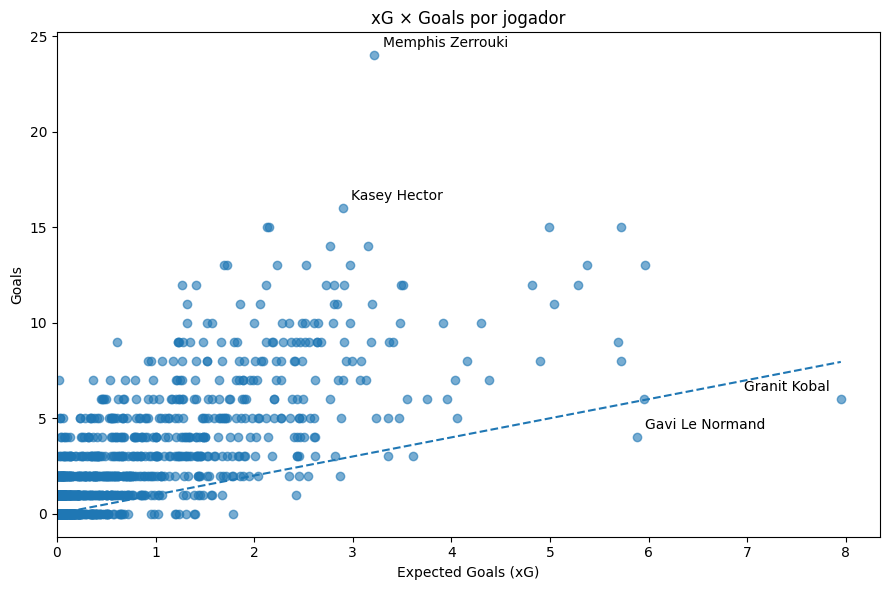

In [123]:
# Criar gráfico de dispersão entre xG e gols

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    desempenho_xg["expected_goals_xg"],
    desempenho_xg["goals"],
    alpha=0.6
)

# Definir o limite da linha de referência a partir do maior xG observado

limite_xg = desempenho_xg["expected_goals_xg"].max()

# Criar linha de referência y = x

plt.plot(
    [0, limite_xg],
    [0, limite_xg],
    linestyle="--"
)

# Ajustar o limite do eixo X

plt.xlim(
    0,
    limite_xg * 1.05
)

# Selecionar os 2 maiores jogadores acima do xG

maiores_over = (
    desempenho_xg
    .sort_values(
        "over_performance",
        ascending=False
    )
    .head(2)
)

# Selecionar os 2 maiores jogadores abaixo do xG

maiores_under = (
    desempenho_xg
    .sort_values(
        "over_performance",
        ascending=True
    )
    .head(2)
)

# Juntar os principais outliers

outliers = pd.concat(
    [
        maiores_over,
        maiores_under
    ]
)

# Adicionar rótulos aos principais outliers

for _, linha in outliers.iterrows():

    deslocamento_x = 6

    if linha["player_name"] == "Granit Kobal":
        deslocamento_x = -70

    plt.annotate(
        linha["player_name"],
        (
            linha["expected_goals_xg"],
            linha["goals"]
        ),
        xytext=(deslocamento_x, 6),
        textcoords="offset points"
    )

# Adicionar títulos e rótulos

plt.xlabel("Expected Goals (xG)")
plt.ylabel("Goals")
plt.title("xG × Goals por jogador")

plt.tight_layout()
plt.show()

### T3.2. Rating por posição

/tmp/ipykernel_37798/1730530934.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


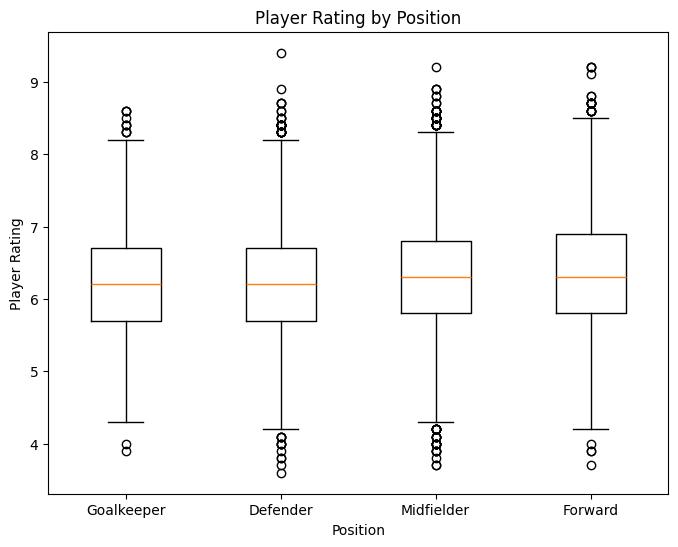

In [124]:
# Filtrar apenas jogadores que participaram da partida

df_rating = df_t2[
    df_t2["minutes_played"] > 0
].copy()

# Criar boxplot do rating por posição

posicoes = [
    "Goalkeeper",
    "Defender",
    "Midfielder",
    "Forward"
]

dados_boxplot = [
    df_rating.loc[
        df_rating["position"] == posicao,
        "player_rating"
    ]
    for posicao in posicoes
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    dados_boxplot,
    labels=posicoes
)

plt.xlabel("Position")
plt.ylabel("Player Rating")
plt.title("Player Rating by Position")

plt.show()

In [125]:
# Calcular medidas de dispersão apenas para jogadores com minutos em campo

dispersao_rating = (
    df_rating.groupby("position")["player_rating"]
    .agg(
        media="mean",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values(
        "desvio_padrao",
        ascending=False
    )
)

display(dispersao_rating)

,media,desvio_padrao,minimo,maximo
position,,,,
Forward,6.355260,0.751795,3.7,9.2
Midfielder,6.313140,0.738402,3.7,9.2
Defender,6.237095,0.721763,3.6,9.4
Goalkeeper,6.205286,0.716960,3.9,8.6


### T3.3 — “Pizza 3D” do gerente

Eu não utilizaria um gráfico de pizza com 24 categorias em 3D.

Com muitas categorias, a comparação entre fatias se torna difícil e o efeito 3D pode distorcer visualmente as proporções.

Como alternativa, eu utilizaria um **gráfico de barras ordenado**, que facilita a comparação entre países e permite identificar rapidamente maiores e menores valores.

Se fosse necessário destacar apenas participação relativa, eu reduziria o número de categorias, agrupando as menores em **“Outros”**.

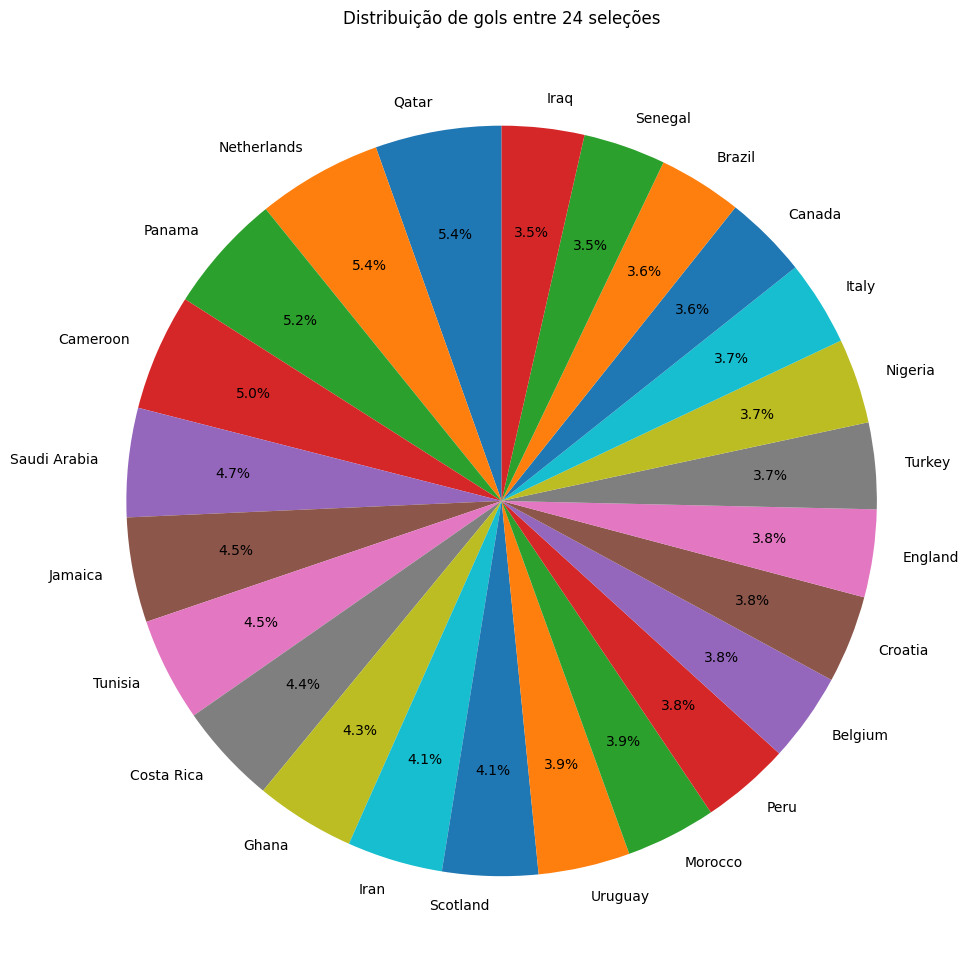

In [126]:
# Criar gráfico de pizza com 24 seleções de forma mais limpa

pizza_24 = (
    resumo_selecao
    .sort_values("gols", ascending=False)
    .head(24)
)

plt.figure(figsize=(10, 10))

plt.pie(
    pizza_24["gols"],
    labels=pizza_24["team"],
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.08,
    pctdistance=0.72
)

plt.title("Distribuição de gols entre 24 seleções")

plt.tight_layout()
plt.show()

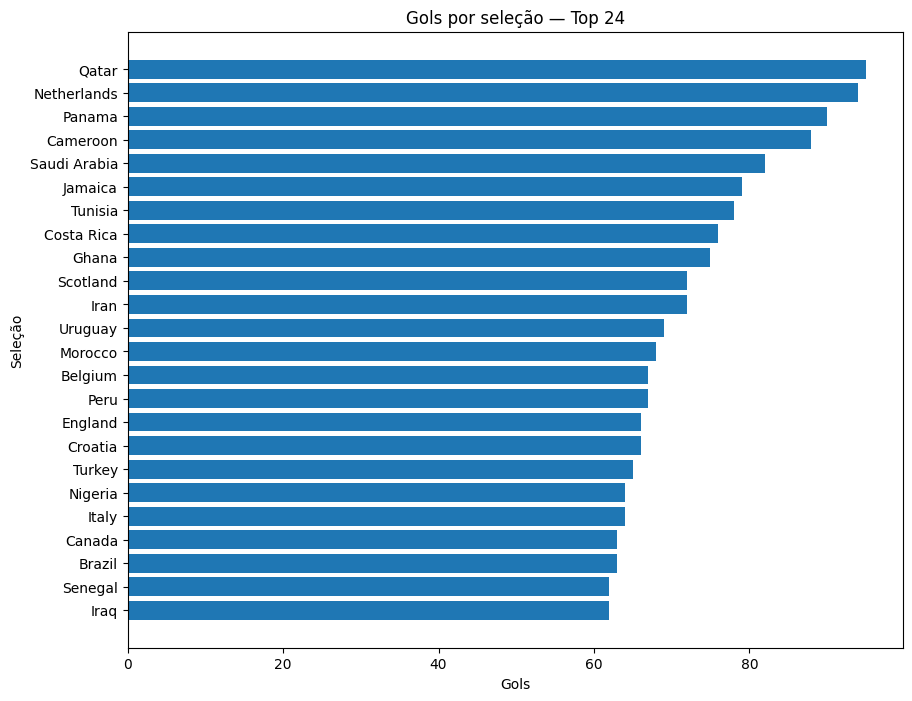

In [127]:
# Criar gráfico de barras com as mesmas 24 seleções para facilitar a comparação

pizza_24_ordenado = (
    pizza_24
    .sort_values("gols", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    pizza_24_ordenado["team"],
    pizza_24_ordenado["gols"]
)

plt.xlabel("Gols")
plt.ylabel("Seleção")
plt.title("Gols por seleção — Top 24")

plt.show()

###T3.4 Bônus front-end

In [128]:
# Preparar dados agregados de jogadores para o front-end

ranking_jogadores = jogadores_t2_90.merge(
    desempenho_xg[
        ["player_id", "over_performance"]
    ],
    on="player_id",
    how="left"
)

ranking_jogadores = ranking_jogadores[
    [
        "player_name",
        "team",
        "goals",
        "minutes_played",
        "goals_per90",
        "over_performance"
    ]
]

# Preparar dados agregados de seleções para o front-end

ranking_selecoes = resumo_selecao[
    [
        "team",
        "gols",
        "assistencias",
        "media_rating",
        "distancia_total_km"
    ]
].copy()

# Converter os dois conjuntos para JSON

json_jogadores = ranking_jogadores.to_json(
    orient="records"
)

json_selecoes = ranking_selecoes.to_json(
    orient="records"
)

print(
    "Jogadores exportados:",
    len(ranking_jogadores)
)

print(
    "Seleções exportadas:",
    len(ranking_selecoes)
)

Jogadores exportados: 1248
Seleções exportadas: 48


In [129]:
# Criar uma página HTML self-contained com rankings de jogadores e seleções

html = f"""
<!DOCTYPE html>
<html lang="pt-BR">

<head>
<meta charset="UTF-8">

<title>FIFA World Cup 2026 — Ranking Interativo</title>

<style>

body {{
    font-family: Arial, sans-serif;
    max-width: 1000px;
    margin: 40px auto;
    padding: 0 20px;
    background: #f7f7f7;
}}

h1 {{
    margin-bottom: 5px;
}}

.subtitulo {{
    color: #555;
    margin-bottom: 30px;
}}

.painel {{
    background: white;
    padding: 25px;
    border-radius: 8px;
}}

.controles {{
    display: flex;
    gap: 15px;
    margin-bottom: 25px;
    flex-wrap: wrap;
}}

select {{
    padding: 8px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    margin-top: 20px;
}}

th, td {{
    padding: 9px;
    border-bottom: 1px solid #ddd;
    text-align: left;
}}

th {{
    background: #f2f2f2;
}}

svg {{
    width: 100%;
    margin-top: 30px;
}}

</style>

</head>

<body>

<div class="painel">

<h1>FIFA World Cup 2026</h1>

<div class="subtitulo">
Ranking interativo de jogadores e seleções
</div>

<div class="controles">

<div>
<label>Tipo:</label>

<select id="tipo" onchange="atualizarMetricas()">
    <option value="jogadores">Jogadores</option>
    <option value="selecoes">Seleções</option>
</select>
</div>

<div>
<label>Métrica:</label>

<select id="metrica" onchange="atualizar()"></select>
</div>

<div>
<label>Top:</label>

<select id="quantidade" onchange="atualizar()">
    <option value="5">5</option>
    <option value="10" selected>10</option>
    <option value="20">20</option>
</select>
</div>

</div>

<table>

<thead>
<tr>
    <th>#</th>
    <th id="coluna_nome">Jogador</th>
    <th id="coluna_extra">Seleção</th>
    <th>Valor</th>
</tr>
</thead>

<tbody id="ranking"></tbody>

</table>

<svg id="grafico"></svg>

</div>

<script>

const jogadores = {json_jogadores};
const selecoes = {json_selecoes};

const metricas = {{

    jogadores: {{
        goals: "Gols",
        goals_per90: "Gols por 90 min",
        over_performance: "Goals - xG"
    }},

    selecoes: {{
        gols: "Gols",
        assistencias: "Assistências",
        media_rating: "Rating médio",
        distancia_total_km: "Distância total (km)"
    }}

}};


function atualizarMetricas() {{

    const tipo =
        document.getElementById("tipo").value;

    const select =
        document.getElementById("metrica");

    select.innerHTML = "";

    Object.entries(metricas[tipo]).forEach(
        ([valor, nome]) => {{

            const option =
                document.createElement("option");

            option.value = valor;
            option.textContent = nome;

            select.appendChild(option);
        }}
    );

    atualizar();
}}


function atualizar() {{

    const tipo =
        document.getElementById("tipo").value;

    const metrica =
        document.getElementById("metrica").value;

    const quantidade =
        Number(
            document.getElementById("quantidade").value
        );

    let dados;

    if (tipo === "jogadores") {{

        dados = jogadores
            .filter(d => d.minutes_played >= 180);

        document.getElementById(
            "coluna_nome"
        ).textContent = "Jogador";

        document.getElementById(
            "coluna_extra"
        ).textContent = "Seleção";

    }} else {{

        dados = selecoes;

        document.getElementById(
            "coluna_nome"
        ).textContent = "Seleção";

        document.getElementById(
            "coluna_extra"
        ).textContent = "";
    }}

    const ranking = [...dados]
        .sort(
            (a, b) => b[metrica] - a[metrica]
        )
        .slice(0, quantidade);

    atualizarTabela(
        ranking,
        tipo,
        metrica
    );

    desenharGrafico(
        ranking,
        tipo,
        metrica
    );
}}


function atualizarTabela(
    ranking,
    tipo,
    metrica
) {{

    const tbody =
        document.getElementById("ranking");

    tbody.innerHTML = "";

    ranking.forEach(
        (item, i) => {{

            const linha =
                document.createElement("tr");

            const nome =
                tipo === "jogadores"
                ? item.player_name
                : item.team;

            const extra =
                tipo === "jogadores"
                ? item.team
                : "";

            linha.innerHTML = `
                <td>${{i + 1}}</td>
                <td>${{nome}}</td>
                <td>${{extra}}</td>
                <td>${{item[metrica].toFixed(2)}}</td>
            `;

            tbody.appendChild(linha);
        }}
    );
}}


function desenharGrafico(
    ranking,
    tipo,
    metrica
) {{

    const svg =
        document.getElementById("grafico");

    svg.innerHTML = "";

    const largura = 900;
    const alturaBarra = 26;
    const espaco = 8;

    const altura =
        ranking.length *
        (alturaBarra + espaco);

    svg.setAttribute(
        "viewBox",
        `0 0 ${{largura}} ${{altura}}`
    );

    const maior =
        Math.max(
            ...ranking.map(
                d => d[metrica]
            )
        );

    ranking.forEach(
        (item, i) => {{

            const nome =
                tipo === "jogadores"
                ? item.player_name
                : item.team;

            const larguraBarra =
                (item[metrica] / maior) * 500;

            // Criar nome

            const texto =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            texto.setAttribute("x", 0);

            texto.setAttribute(
                "y",
                i * (alturaBarra + espaco) + 19
            );

            texto.textContent = nome;

            svg.appendChild(texto);

            // Criar barra

            const barra =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "rect"
                );

            barra.setAttribute("x", 230);

            barra.setAttribute(
                "y",
                i * (alturaBarra + espaco)
            );

            barra.setAttribute(
                "width",
                larguraBarra
            );

            barra.setAttribute(
                "height",
                alturaBarra
            );

            barra.setAttribute(
                "rx",
                4
            );

            svg.appendChild(barra);

            // Criar valor

            const valor =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            valor.setAttribute(
                "x",
                240 + larguraBarra
            );

            valor.setAttribute(
                "y",
                i * (alturaBarra + espaco) + 19
            );

            valor.textContent =
                item[metrica].toFixed(2);

            svg.appendChild(valor);

        }}
    );
}}

atualizarMetricas();

</script>

</body>

</html>
"""

# Salvar a página HTML

with open(
    "ranking_interativo.html",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(html)

print(
    "Arquivo criado: ranking_interativo.html"
)

Arquivo criado: ranking_interativo.html


# Parte 4 - Pergunta de negócio + comunicação

###T4.1 5 jogadores mais subvalorizados (alto impacto, baixo rating)

In [130]:
# Considerar apenas registros de jogadores que efetivamente participaram da partida

base_negocio = df_t2[
    df_t2["minutes_played"] > 0
].copy()

# Criar rating ponderado pelos minutos jogados

base_negocio["rating_x_minutos"] = (
    base_negocio["player_rating"] *
    base_negocio["minutes_played"]
)

In [131]:
# Agregar métricas ofensivas e rating por jogador

jogadores_negocio = (
    base_negocio.groupby(
        ["player_id", "player_name", "team"],
        as_index=False
    )
    .agg(
        goals=("goals", "sum"),
        assists=("assists", "sum"),
        key_passes=("key_passes", "sum"),
        minutes_played=("minutes_played", "sum"),
        rating_x_minutos=("rating_x_minutos", "sum")
    )
)

# Calcular rating médio ponderado pelos minutos jogados

jogadores_negocio["player_rating"] = (
    jogadores_negocio["rating_x_minutos"] /
    jogadores_negocio["minutes_played"]
)

# Manter apenas jogadores com pelo menos 90 minutos

jogadores_negocio = jogadores_negocio[
    jogadores_negocio["minutes_played"] >= 90
].copy()

In [132]:
# Calcular métricas ofensivas por 90 minutos

jogadores_negocio["goals_per90"] = (
    jogadores_negocio["goals"] /
    jogadores_negocio["minutes_played"] * 90
)

jogadores_negocio["assists_per90"] = (
    jogadores_negocio["assists"] /
    jogadores_negocio["minutes_played"] * 90
)

jogadores_negocio["key_passes_per90"] = (
    jogadores_negocio["key_passes"] /
    jogadores_negocio["minutes_played"] * 90
)

In [133]:
# Transformar as métricas em percentis para colocá-las na mesma escala

for coluna in [
    "goals_per90",
    "assists_per90",
    "key_passes_per90"
]:
    jogadores_negocio[f"{coluna}_pct"] = (
        jogadores_negocio[coluna].rank(pct=True)
    )

# Criar score de impacto ofensivo de 0 a 100

jogadores_negocio["impacto"] = (
    jogadores_negocio[
        [
            "goals_per90_pct",
            "assists_per90_pct",
            "key_passes_per90_pct"
        ]
    ].mean(axis=1) * 100
)

In [134]:
# Calcular a mediana do rating dos jogadores elegíveis

mediana_rating = jogadores_negocio[
    "player_rating"
].median()

# Selecionar jogadores abaixo da mediana com maior impacto ofensivo

subvalorizados = (
    jogadores_negocio[
        jogadores_negocio["player_rating"] < mediana_rating
    ]
    .sort_values(
        "impacto",
        ascending=False
    )
    .head(5)
)

display(
    subvalorizados[
        [
            "player_name",
            "team",
            "goals",
            "assists",
            "key_passes",
            "minutes_played",
            "player_rating",
            "impacto"
        ]
    ]
)

print(
    "Mediana do rating:",
    round(mediana_rating, 2)
)

,player_name,team,goals,assists,key_passes,minutes_played,player_rating,impacto
74,Rodri Mikel,Spain,6,6,29,1528,6.176047,87.152778
802,Michael Brown,Panama,9,7,30,1761,6.177456,86.832265
1029,Edouard Ndiaye,Senegal,5,6,59,2051,6.136909,86.191239
1143,Nicolas Anguissa,Cameroon,8,4,27,1527,6.012312,83.760684
299,Aleksandar Lukic,Serbia,2,7,40,1558,6.199551,82.612179


Mediana do rating: 6.2
